In [1]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [6]:
import cv2, os
import tensorflow as tf

data_path = "dataset/images/train/"
classes = ['happy', 'sad']   # choose 2 for binary classification

In [7]:
X, y = [], []
for idx, emotion in enumerate(classes):
    folder = os.path.join(data_path, emotion)
    for file in os.listdir(folder)[:1000]:   # small subset for speed
        img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (48, 48))
        X.append(img.flatten())   # flatten 48x48 → 2304 features
        y.append(idx)

X = np.array(X) / 255.0
y = np.array(y)
print("Shape:", X.shape, y.shape)

Shape: (2000, 2304) (2000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
class Perceptron:
    def __init__(self, n_features, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.W = np.zeros(n_features)
        self.b = 0
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        for epoch in range(self.epochs):
            z = np.dot(X, self.W) + self.b
            y_pred = self.sigmoid(z)
            loss = -np.mean(y*np.log(y_pred+1e-9) + (1-y)*np.log(1-y_pred+1e-9))
            self.loss_history.append(loss)

            # Gradient descent update
            grad_W = np.dot(X.T, (y_pred - y)) / X.shape[0]
            grad_b = np.mean(y_pred - y)
            self.W -= self.lr * grad_W
            self.b -= self.lr * grad_b

            if epoch % 10 == 0:
                print(f"Epoch {epoch:3d} | Loss: {loss:.4f}")

    def predict(self, X):
        y_pred = self.sigmoid(np.dot(X, self.W) + self.b)
        return (y_pred >= 0.5).astype(int)


In [10]:
model = Perceptron(n_features=X_train.shape[1], lr=0.1, epochs=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")


Epoch   0 | Loss: 0.6931
Epoch  10 | Loss: 2.0720
Epoch  20 | Loss: 2.0700
Epoch  30 | Loss: 2.2387
Epoch  40 | Loss: 2.4300
Epoch  50 | Loss: 2.6335
Epoch  60 | Loss: 2.8444
Epoch  70 | Loss: 3.0602
Epoch  80 | Loss: 3.2794
Epoch  90 | Loss: 3.5003
Test Accuracy: 50.25%


In [11]:
model = Perceptron(n_features=X_train.shape[1], lr=0.1, epochs=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")


Epoch   0 | Loss: 0.6931
Epoch  10 | Loss: 2.0720
Epoch  20 | Loss: 2.0700
Epoch  30 | Loss: 2.2387
Epoch  40 | Loss: 2.4300
Epoch  50 | Loss: 2.6335
Epoch  60 | Loss: 2.8444
Epoch  70 | Loss: 3.0602
Epoch  80 | Loss: 3.2794
Epoch  90 | Loss: 3.5003
Test Accuracy: 50.25%


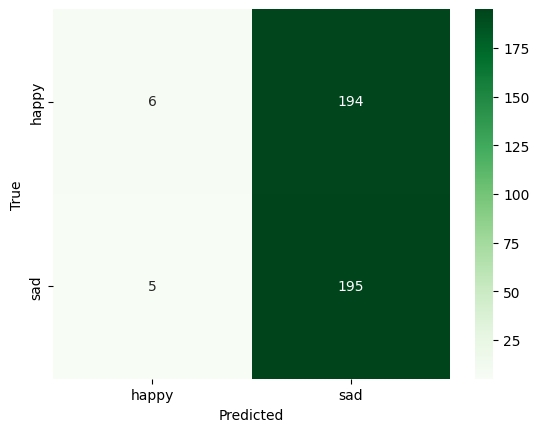

In [12]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()


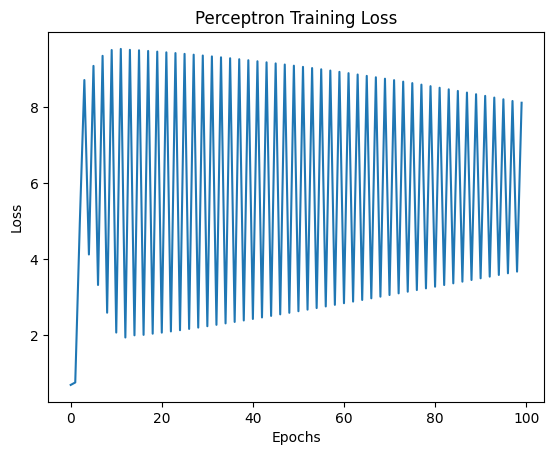

In [13]:
plt.plot(model.loss_history)
plt.title("Perceptron Training Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.show()


#### Compareing Activations

In [16]:
# Step Activation (Classic Perceptron)
def step_activation(z):
    return np.where(z >= 0, 1, 0)

class StepPerceptron(Perceptron):
    def sigmoid(self, z):
        return step_activation(z)


In [17]:
#traning and testing 
step_model = StepPerceptron(n_features=X_train.shape[1], lr=0.1, epochs=50)
step_model.fit(X_train, y_train)
y_pred_step = step_model.predict(X_test)
print("Accuracy (Step):", accuracy_score(y_test, y_pred_step))


Epoch   0 | Loss: 10.3616
Epoch  10 | Loss: 10.3616
Epoch  20 | Loss: 10.3616
Epoch  30 | Loss: 10.3487
Epoch  40 | Loss: 10.3487
Accuracy (Step): 0.5


In [20]:
# ReLU Activation (Rectified Linear Unit)
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)
    


NameError: name 'self' is not defined

In [21]:
# modifing it 
z = np.dot(X, W) + b
y_pred = relu(z)
# Apply small derivative-based update
grad_W = np.dot(X.T, (y_pred - y) * relu_derivative(z)) / X.shape[0]
grad_b = np.mean((y_pred - y) * relu_derivative(z))


NameError: name 'W' is not defined